## Lecure traj 

In [11]:
# ============================================================
# CELL X — Chargement SBET entre deux timestamps
# ============================================================
import sys
import numpy as np

sys.path.append("/home/b085164/PDM_Romain_Defferrard/ESO-PDM")
from lib.trajectory import Trajectory

T_START = 316022.0
T_END   = 316095.0
T_GRID  = np.arange(T_START, T_END, 0.1)

SBET_CFG = {"type": "SBET", "timeRef": "GPS"}

SBET_PATH = "/media/b085164/Elements/ECCR/ODyN/base/out/ODyN_GNSS_INS.out"   # ← à adapter

print("Chargement SBET...")
trj = Trajectory.fromSBET(SBET_PATH, SBET_CFG)
trj.label = "SBET"
trj.interp(T_GRID, updateSelf=True)
trj.estimate_q_l2e(interp=True)
print("OK")

Chargement SBET...
Loading file /media/b085164/Elements/ECCR/ODyN/base/out/ODyN_GNSS_INS.out


OK


⚠️  Pas de sigma trouvé — fichier smrmsg nécessaire


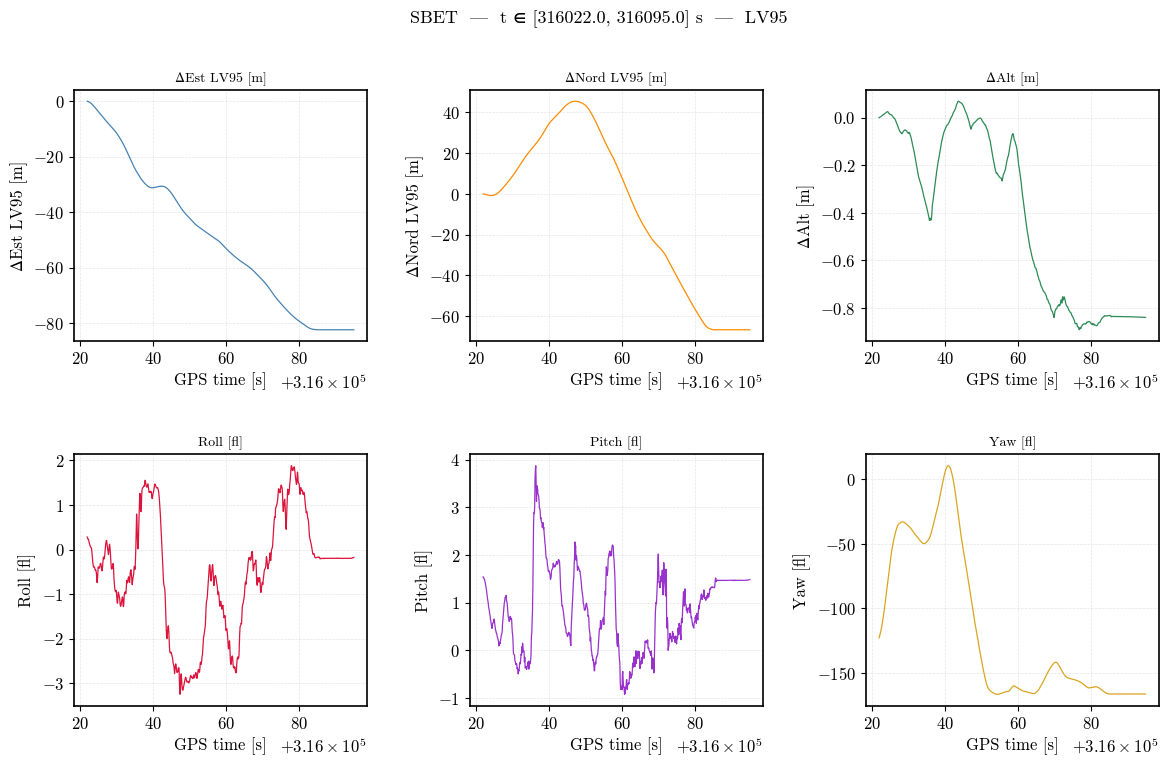

In [12]:
# ============================================================
# CELL X+1 — Plot XYZ (LV95), RPY et Sigma XYZ
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lib.rotations import quat2euler
from pyproj import Transformer

t = trj.t_interp

# ── position LV95 (MN95 / CH1903+) ──────────────────────────
transformer = Transformer.from_crs("EPSG:4326", "EPSG:2056", always_xy=True)

lon = np.degrees(trj.lla_interp[:, 1])
lat = np.degrees(trj.lla_interp[:, 0])
alt = trj.lla_interp[:, 2]

E, N = transformer.transform(lon, lat)  # Est, Nord [m] LV95

dE  = E   - E[0]
dN  = N   - N[0]
dAlt = alt - alt[0]

# ── RPY depuis quaternion interpolé ─────────────────────────
rpy   = np.array([quat2euler(q) for q in trj.q_interp])
roll  = np.degrees(rpy[:, 0])
pitch = np.degrees(rpy[:, 1])
yaw   = np.degrees(rpy[:, 2])

# ── sigma ────────────────────────────────────────────────────
has_sigma = False
for attr in ["sigma_pos", "std_pos", "cov_pos", "sigma"]:
    if hasattr(trj, attr):
        sig = getattr(trj, attr)
        sx, sy, sz = sig[:, 0], sig[:, 1], sig[:, 2]
        has_sigma = True
        print(f"Sigma trouvé : trj.{attr}")
        break
if not has_sigma:
    print("⚠️  Pas de sigma trouvé — fichier smrmsg nécessaire")

# ── figure ──────────────────────────────────────────────────
n_rows = 2 + int(has_sigma)
fig = plt.figure(figsize=(14, 4 * n_rows))
fig.suptitle(f"SBET  |  t ∈ [{T_START}, {T_END}] s  |  LV95", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(n_rows, 3, figure=fig, hspace=0.45, wspace=0.35)

# — Row 0 : ΔEst  ΔNord  ΔAlt (LV95) ————————————————————
for i, (lbl, d, c) in enumerate(zip(
        ["ΔEst LV95 [m]", "ΔNord LV95 [m]", "ΔAlt [m]"],
        [dE, dN, dAlt],
        ["steelblue", "darkorange", "seagreen"])):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(t, d, color=c, linewidth=0.9)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel("GPS time [s]")
    ax.set_ylabel(lbl)
    ax.grid(True, linestyle="--", alpha=0.5)

# — Row 1 : Roll / Pitch / Yaw ———————————————————————————
for i, (lbl, d, c) in enumerate(zip(
        ["Roll [°]", "Pitch [°]", "Yaw [°]"],
        [roll, pitch, yaw],
        ["crimson", "darkorchid", "goldenrod"])):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(t, d, color=c, linewidth=0.9)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel("GPS time [s]")
    ax.set_ylabel(lbl)
    ax.grid(True, linestyle="--", alpha=0.5)

# — Row 2 : Sigma XYZ (si dispo) —————————————————————————
if has_sigma:
    for i, (lbl, d, c) in enumerate(zip(
            ["σ X [m]", "σ Y [m]", "σ Z [m]"],
            [sx, sy, sz],
            ["steelblue", "darkorange", "seagreen"])):
        ax = fig.add_subplot(gs[2, i])
        ax.plot(t, d, color=c, linewidth=0.9)
        ax.set_title(lbl, fontsize=10)
        ax.set_xlabel("GPS time [s]")
        ax.set_ylabel(lbl)
        ax.grid(True, linestyle="--", alpha=0.5)

plt.show()